正在计算全局 Spearman 相关性矩阵...


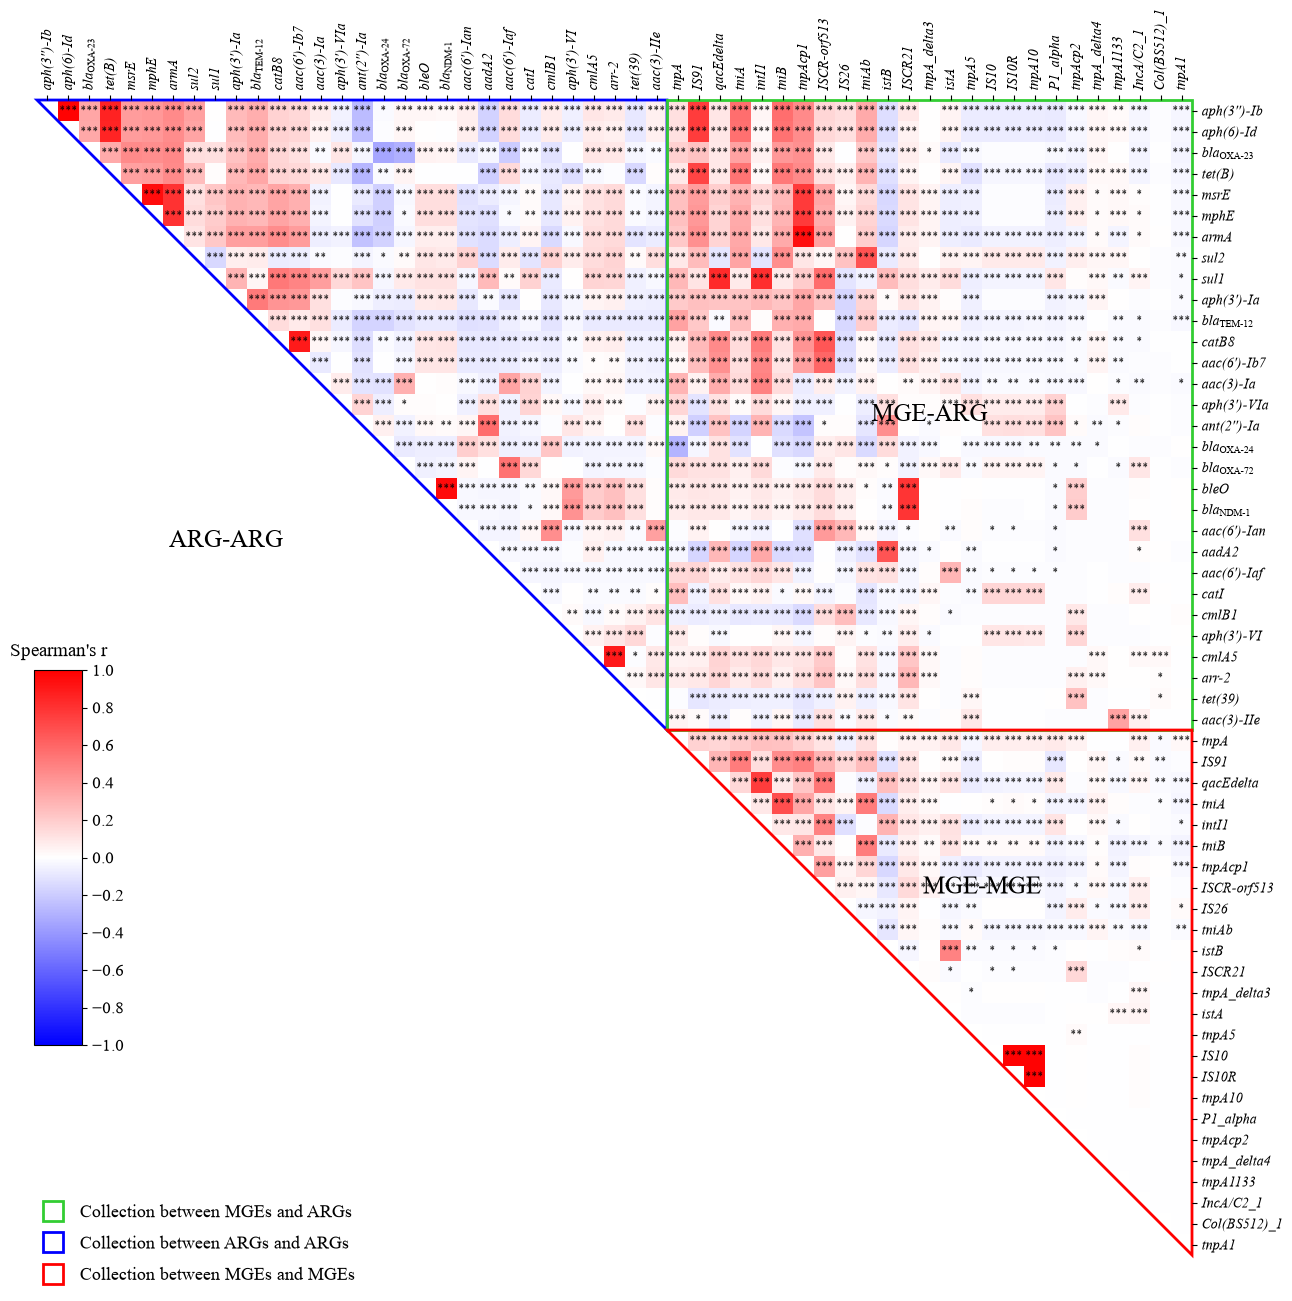

修改完成！坐标轴上的 ARG 和 MGE 基因名已全部更新为非加粗的斜体新罗马字体。


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from matplotlib.patches import Polygon, Rectangle
import matplotlib.lines as mlines
import matplotlib as mpl

# ================= 1. 读取数据与准备工作 =================
df = pd.read_csv(r'D:\A.baumannii\data\ARGs_MGEs_merged.csv')

# 提取特征名
arg_cols = df.columns[1:31].tolist()
mge_cols = df.columns[31:56].tolist()

# ======== 新增核心修改：格式化基因名称 (大写转小写，处理 bla 下标) ========
def format_gene_name(gene):
    gene_str = str(gene)
    # 1. 遇到 APH, AAC, ANT，将前3个字母变为小写
    if gene_str.startswith(("APH", "AAC", "ANT")):
        gene_str = gene_str[:3].lower() + gene_str[3:]
        
    # 2. 遇到 bla，变为斜体且后缀转为正体下标
    if gene_str.startswith("bla"):
        suffix = gene_str[3:]
        suffix_math = suffix.replace('-', r'}\text{-}\mathrm{')
        return rf'$\mathit{{bla}}_{{\mathrm{{{suffix_math}}}}}$'
    
    return gene_str

# 将格式化应用到 DataFrame 的列名上
rename_dict = {col: format_gene_name(col) for col in arg_cols}
df.rename(columns=rename_dict, inplace=True)

# 更新列名列表
arg_cols = [rename_dict[col] for col in arg_cols]
all_cols = arg_cols + mge_cols
# =========================================================================

n_args = len(arg_cols)
n_mges = len(mge_cols)
N = len(all_cols)

# ================= 2. 计算大矩阵与 P值 星号 =================
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)
pval_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

print("正在计算全局 Spearman 相关性矩阵...")
for col1 in all_cols:
    for col2 in all_cols:
        r, p = spearmanr(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = r
        pval_matrix.loc[col1, col2] = p

# 显著性星号转换函数
def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

stars_matrix = pval_matrix.map(get_stars)

# ================= 3. 生成下三角遮罩 (Mask) =================
mask = np.tril(np.ones((N, N), dtype=bool), k=0)

# ================= 4. 设置画布与全局字体 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# 新增：确保渲染 bla 公式时也使用 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'

fig, ax = plt.subplots(figsize=(16, 15))

# ================= 5. 绘制核心热图 =================
sns.heatmap(
    corr_matrix, 
    mask=mask,
    cmap='bwr', 
    center=0, vmin=-1, vmax=1,
    annot=stars_matrix, fmt='', 
    annot_kws={"size": 8, "color": "black", "ha": "center", "va": "center"},
    cbar=False,      
    square=True,     
    linewidths=0,    
    ax=ax
)

# 坐标轴移到顶部和右侧
ax.xaxis.tick_top()
ax.yaxis.tick_right()

# 获取刻度标签对象，以便后续修改样式
xtick_labels = ax.get_xticklabels()
ytick_labels = ax.get_yticklabels()

plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')

# ================= 【修改核心点】统一设置 ARG 和 MGE 基因名为斜体 =================
def set_gene_style(labels, target_list):
    for label in labels:
        text = label.get_text()
        if text in target_list:
            # 如果是 bla 开头的公式 (带 $ 符号)，跳过，以保留其公式内部已经设置好的非加粗样式
            if not text.startswith('$'):
                label.set_style('italic')

# 此处原来是 arg_cols，现在改成 all_cols，这样 MGE 也会变成斜体了！
set_gene_style(xtick_labels, all_cols)
set_gene_style(ytick_labels, all_cols)
# =========================================================================

# ================= 6. 绘制高逼格的分区边界框 =================
# 1. ARG-ARG 区域蓝框
arg_poly = Polygon([[0,0], [n_args,0], [n_args, n_args]], 
                   fill=False, edgecolor='blue', lw=2, clip_on=False)
ax.add_patch(arg_poly)
ax.text(n_args * 0.3, n_args * 0.7, 'ARG-ARG', color='black', 
        fontsize=18, ha='center', va='center')

# 2. MGE-ARG 区域绿框
mge_arg_rect = Rectangle((n_args, 0), n_mges, n_args, 
                         fill=False, edgecolor='limegreen', lw=2, clip_on=False)
ax.add_patch(mge_arg_rect)
ax.text(n_args + n_mges * 0.5, n_args * 0.5, 'MGE-ARG', color='black', 
        fontsize=18, ha='center', va='center')

# 3. MGE-MGE 区域红框
mge_poly = Polygon([[n_args, n_args], [n_args+n_mges, n_args], [n_args+n_mges, n_args+n_mges]], 
                   fill=False, edgecolor='red', lw=2, clip_on=False)
ax.add_patch(mge_poly)
ax.text(n_args + n_mges * 0.6, n_args + n_mges * 0.3, 'MGE-MGE', color='black', 
        fontsize=18, ha='center', va='center')

# ================= 7. 绘制左下角专属图例与 Colorbar =================
# 1. 添加 Colorbar
cbar_ax = fig.add_axes([0.15, 0.25, 0.03, 0.25]) 
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=plt.get_cmap('bwr'), 
                               norm=norm, orientation='vertical')
cb.set_ticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
cb.ax.tick_params(labelsize=12)
cbar_ax.set_title("Spearman's r", fontsize=14, pad=10)

# 2. 添加框线图例
legend_elements = [
    mlines.Line2D([0], [0], marker='s', color='w', label='Collection between MGEs and ARGs',
                  markerfacecolor='w', markeredgecolor='limegreen', markersize=14, markeredgewidth=2),
    mlines.Line2D([0], [0], marker='s', color='w', label='Collection between ARGs and ARGs',
                  markerfacecolor='w', markeredgecolor='blue', markersize=14, markeredgewidth=2),
    mlines.Line2D([0], [0], marker='s', color='w', label='Collection between MGEs and MGEs',
                  markerfacecolor='w', markeredgecolor='red', markersize=14, markeredgewidth=2)
]
fig.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.14, 0.08),
           frameon=False, fontsize=13, handletextpad=0.5, labelspacing=0.8)

# 保存与展示
plt.savefig('Triangular_Correlation_Heatmap_Italic.png', dpi=600, bbox_inches='tight')
plt.show()

print("修改完成！坐标轴上的 ARG 和 MGE 基因名已全部更新为非加粗的斜体新罗马字体。")
